# Irrigation Kaggle Competition
## Homework 2
### Dirks Wright


In [1]:
### import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import optuna


In [2]:
### import dataset
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
### Data Preprocessing
# Encode categorical variables
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove the target variable from categorical columns
if 'Irrigation_Need' in categorical_cols:
    categorical_cols.remove('Irrigation_Need')

# Encode categorical features
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    df_test[col] = le.transform(df_test[col].astype(str))
    label_encoders[col] = le

# Encode target variable
le_target = LabelEncoder()
df['Irrigation_Need'] = le_target.fit_transform(df['Irrigation_Need'])

# Separate features and target
X = df.drop(['id', 'Irrigation_Need'], axis=1)
y = df['Irrigation_Need']

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=222, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Feature count: {X_train.shape[1]}")
print(f"Classes: {np.unique(y)}")

Training set size: (504000, 19)
Validation set size: (126000, 19)
Feature count: 19
Classes: [0 1 2]


In [4]:
### BASELINE MODELS (No Tuning)
print("="*60)
print("BASELINE MODELS (No Hyperparameter Tuning)")
print("="*60)

# Setup cross-validation for baseline evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=222)

# BASELINE: Random Forest (Bagging)
print("\n--- BASELINE: Random Forest (Bagging) ---")
rf_baseline = RandomForestClassifier(random_state=222, n_jobs=-1)
rf_cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=skf, scoring='f1_weighted')
rf_baseline.fit(X_train, y_train)
y_val_pred_rf_baseline = rf_baseline.predict(X_val)

print(f"Random Forest CV F1 Score: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")
print(f"Random Forest Validation F1 Score: {f1_score(y_val, y_val_pred_rf_baseline, average='weighted'):.4f}")
print(f"Random Forest Validation Accuracy: {accuracy_score(y_val, y_val_pred_rf_baseline):.4f}")

# BASELINE: XGBoost (Boosting)
print("\n--- BASELINE: XGBoost (Boosting) ---")
xgb_baseline = XGBClassifier(random_state=222, enable_categorical=False)
xgb_cv_scores = cross_val_score(xgb_baseline, X_train, y_train, cv=skf, scoring='f1_weighted')
xgb_baseline.fit(X_train, y_train)
y_val_pred_xgb_baseline = xgb_baseline.predict(X_val)

print(f"XGBoost CV F1 Score: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")
print(f"XGBoost Validation F1 Score: {f1_score(y_val, y_val_pred_xgb_baseline, average='weighted'):.4f}")
print(f"XGBoost Validation Accuracy: {accuracy_score(y_val, y_val_pred_xgb_baseline):.4f}")

print("\n" + "="*60)
print("BASELINE MODEL COMPARISON")
print("="*60)
baseline_comparison = pd.DataFrame({
    'Model': ['Random Forest (Baseline)', 'XGBoost (Baseline)'],
    'CV F1 Mean': [rf_cv_scores.mean(), xgb_cv_scores.mean()],
    'CV F1 Std': [rf_cv_scores.std(), xgb_cv_scores.std()],
    'Validation F1': [
        f1_score(y_val, y_val_pred_rf_baseline, average='weighted'),
        f1_score(y_val, y_val_pred_xgb_baseline, average='weighted')
    ],
    'Validation Accuracy': [
        accuracy_score(y_val, y_val_pred_rf_baseline),
        accuracy_score(y_val, y_val_pred_xgb_baseline)
    ]
})
print(baseline_comparison.to_string(index=False))

BASELINE MODELS (No Hyperparameter Tuning)

--- BASELINE: Random Forest (Bagging) ---
Random Forest CV F1 Score: 0.9850 (+/- 0.0001)
Random Forest Validation F1 Score: 0.9851
Random Forest Validation Accuracy: 0.9852

--- BASELINE: XGBoost (Boosting) ---
XGBoost CV F1 Score: 0.9840 (+/- 0.0003)
XGBoost Validation F1 Score: 0.9843
XGBoost Validation Accuracy: 0.9844

BASELINE MODEL COMPARISON
                   Model  CV F1 Mean  CV F1 Std  Validation F1  Validation Accuracy
Random Forest (Baseline)    0.985025   0.000059       0.985078             0.985151
      XGBoost (Baseline)    0.984037   0.000155       0.984304             0.984365


In [7]:
### TUNED BAGGING MODEL: Random Forest with Optuna
print("="*60)
print("TUNED BAGGING MODEL: Random Forest with Optuna")
print("="*60)

def rf_objective(trial):
    # Define hyperparameters to tune
    n_estimators = trial.suggest_categorical('n_estimators', [100, 200, 300])
    max_depth = trial.suggest_categorical('max_depth', [5, 10, 15, None])
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 5, 10])
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 2, 4])
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    
    # Create model with suggested parameters
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=222,
        n_jobs=-1
    )
    
    # Evaluate using cross-validation
    cv_scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='f1_weighted')
    return cv_scores.mean()

# Create and run Optuna study
rf_study = optuna.create_study(direction='maximize')
print("Optimizing Random Forest hyperparameters with Optuna...")
rf_study.optimize(rf_objective, n_trials=10, show_progress_bar=True)

# Get best parameters and create best model
best_rf_params = rf_study.best_params
best_rf = RandomForestClassifier(**best_rf_params, random_state=222, n_jobs=-1)
best_rf.fit(X_train, y_train)

print(f"\nBest Random Forest Parameters:")
print(best_rf_params)
print(f"Best CV F1 Score: {rf_study.best_value:.4f}")

# Evaluate on validation set
y_val_pred_rf = best_rf.predict(X_val)

print(f"\n--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_val_pred_rf, average='weighted'):.4f}")
print(f"F1 Score (macro): {f1_score(y_val, y_val_pred_rf, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf))

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Important Features (Random Forest):")
print(feature_importance_rf.head(10))



[I 2026-04-15 19:41:51,569] A new study created in memory with name: no-name-939c1096-6953-41e5-905e-52d9347a09a7


TUNED BAGGING MODEL: Random Forest with Optuna
Optimizing Random Forest hyperparameters with Optuna...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-15 19:42:48,152] Trial 0 finished with value: 0.9829273393021541 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9829273393021541.
[I 2026-04-15 19:45:52,221] Trial 1 finished with value: 0.9850511206075028 and parameters: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9850511206075028.
[I 2026-04-15 19:46:24,584] Trial 2 finished with value: 0.8701918952368027 and parameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with value: 0.9850511206075028.
[I 2026-04-15 19:47:28,675] Trial 3 finished with value: 0.8718657822283251 and parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9850511206075

In [8]:
### TUNED BOOSTING MODEL: XGBoost with Optuna
print("\n" + "="*60)
print("BOOSTING MODEL: XGBoost Classifier")
print("="*60)

### TUNED BOOSTING MODEL: XGBoost with Optuna
print("\n" + "="*60)
print("TUNED BOOSTING MODEL: XGBoost with Optuna")
print("="*60)

def xgb_objective(trial):
    # Define hyperparameters to tune
    n_estimators = trial.suggest_categorical('n_estimators', [100, 200, 300])
    max_depth = trial.suggest_categorical('max_depth', [3, 5, 7])
    learning_rate = trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1])
    subsample = trial.suggest_categorical('subsample', [0.8, 0.9, 1.0])
    colsample_bytree = trial.suggest_categorical('colsample_bytree', [0.8, 0.9, 1.0])
    
    # Create model with suggested parameters
    xgb = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=222,
        enable_categorical=False
    )
    
    # Evaluate using cross-validation
    cv_scores = cross_val_score(xgb, X_train, y_train, cv=skf, scoring='f1_weighted')
    return cv_scores.mean()

# Create and run Optuna study
xgb_study = optuna.create_study(direction='maximize')
print("Optimizing XGBoost hyperparameters with Optuna...")
xgb_study.optimize(xgb_objective, n_trials=10, show_progress_bar=True)

# Get best parameters and create best model
best_xgb_params = xgb_study.best_params
best_xgb = XGBClassifier(**best_xgb_params, random_state=222, enable_categorical=False)
best_xgb.fit(X_train, y_train)

print(f"\nBest XGBoost Parameters:")
print(best_xgb_params)
print(f"Best CV F1 Score: {xgb_study.best_value:.4f}")

# Evaluate on validation set
y_val_pred_xgb = best_xgb.predict(X_val)

print(f"\n--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_xgb):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_val_pred_xgb, average='weighted'):.4f}")
print(f"F1 Score (macro): {f1_score(y_val, y_val_pred_xgb, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb))

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Important Features (XGBoost):")
print(feature_importance_xgb.head(10))

[I 2026-04-15 20:00:14,089] A new study created in memory with name: no-name-ff8c8506-7651-4083-872d-143afbe1664f



BOOSTING MODEL: XGBoost Classifier

TUNED BOOSTING MODEL: XGBoost with Optuna
Optimizing XGBoost hyperparameters with Optuna...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-15 20:00:59,425] Trial 0 finished with value: 0.9834359310882576 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 1.0}. Best is trial 0 with value: 0.9834359310882576.
[I 2026-04-15 20:01:33,282] Trial 1 finished with value: 0.9832013774116142 and parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 1.0}. Best is trial 0 with value: 0.9834359310882576.
[I 2026-04-15 20:02:38,659] Trial 2 finished with value: 0.9837607432112023 and parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.9}. Best is trial 2 with value: 0.9837607432112023.
[I 2026-04-15 20:04:03,173] Trial 3 finished with value: 0.9840883623963524 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.9}. Best is trial 3 with value: 0.9840883623963524.
[I 2026-04-15 20:04:56


MODEL COMPARISON

MODEL COMPARISON

Comprehensive Model Performance Summary:
                   Model  CV F1 Score  Validation Accuracy  Validation F1 (Weighted)  Validation F1 (Macro)
Random Forest (Baseline)     0.985025             0.985151                  0.985078               0.969713
      XGBoost (Baseline)     0.984037             0.984365                  0.984304               0.970199
   Random Forest (Tuned)     0.985051             0.985230                  0.985153               0.969903
         XGBoost (Tuned)     0.984210             0.984532                  0.984470               0.970834

*** BEST TUNED MODEL: Random Forest (Tuned) ***

Improvement from tuning:
Random Forest: -0.0006 F1 points
XGBoost: 0.0002 F1 points


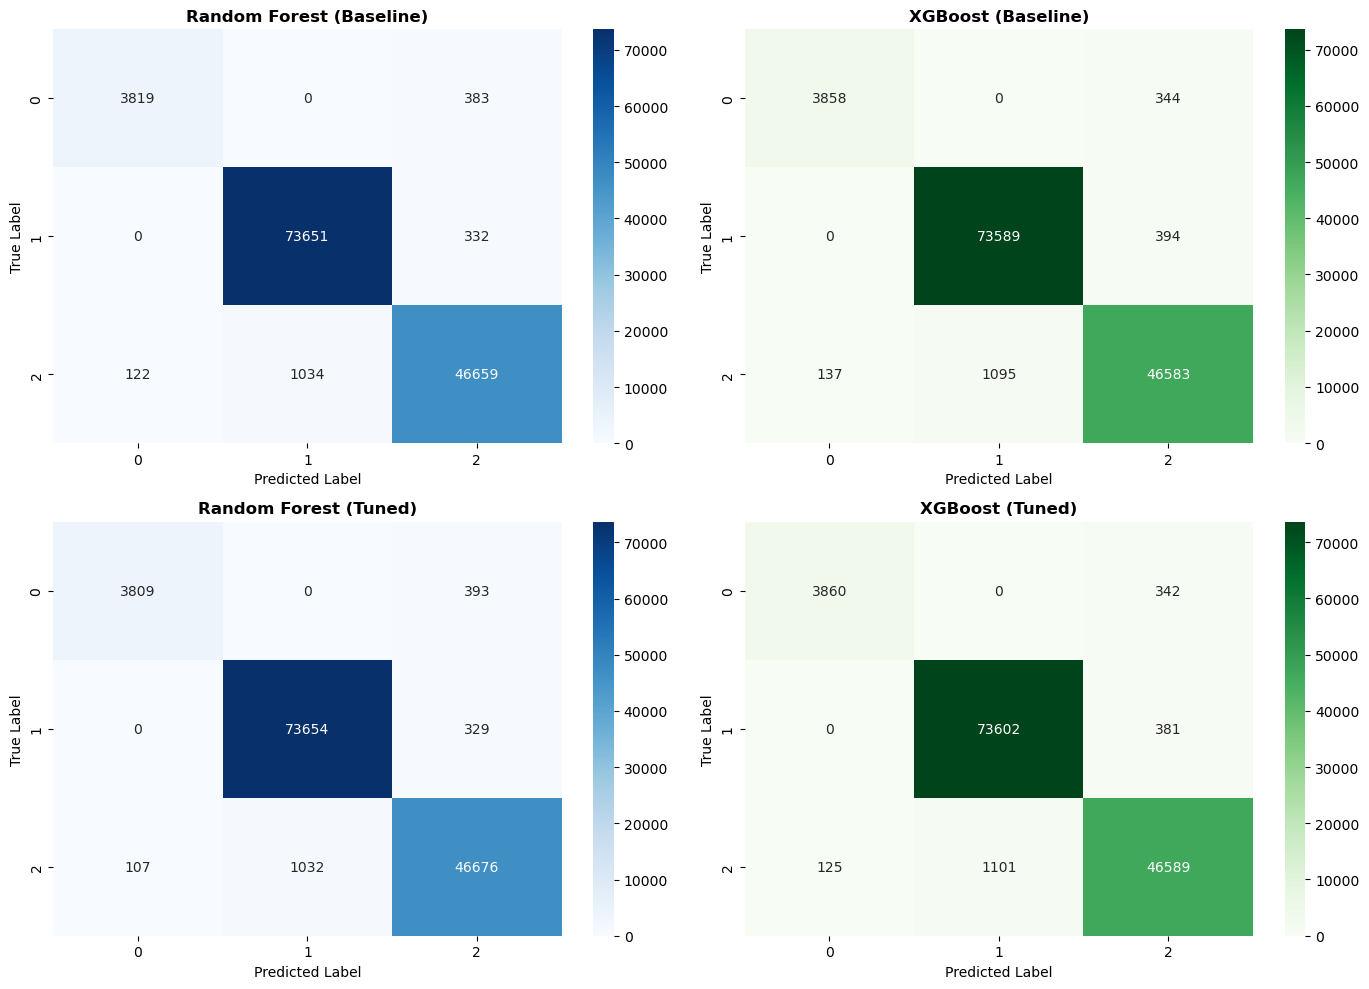

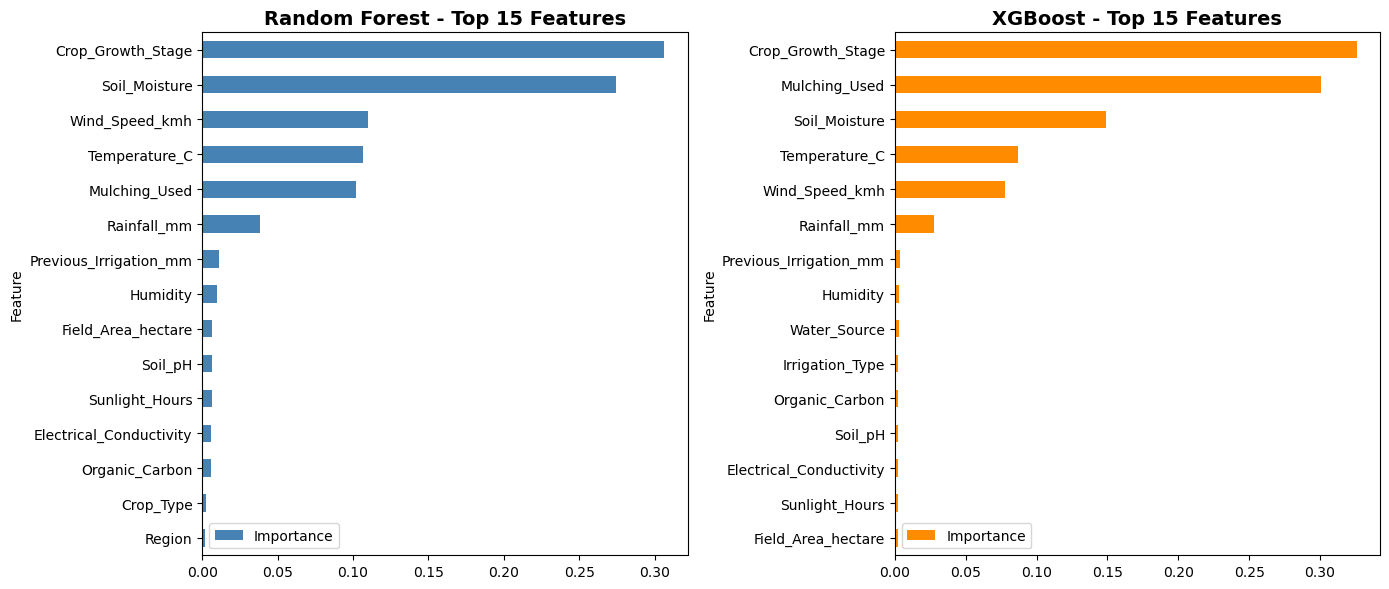

In [9]:
### MODEL COMPARISON
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

### MODEL COMPARISON
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Create comprehensive comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Random Forest (Baseline)', 'XGBoost (Baseline)', 'Random Forest (Tuned)', 'XGBoost (Tuned)'],
    'CV F1 Score': [
        rf_cv_scores.mean(), 
        xgb_cv_scores.mean(),
        rf_study.best_value, 
        xgb_study.best_value
    ],
    'Validation Accuracy': [
        accuracy_score(y_val, y_val_pred_rf_baseline),
        accuracy_score(y_val, y_val_pred_xgb_baseline),
        accuracy_score(y_val, y_val_pred_rf),
        accuracy_score(y_val, y_val_pred_xgb)
    ],
    'Validation F1 (Weighted)': [
        f1_score(y_val, y_val_pred_rf_baseline, average='weighted'),
        f1_score(y_val, y_val_pred_xgb_baseline, average='weighted'),
        f1_score(y_val, y_val_pred_rf, average='weighted'),
        f1_score(y_val, y_val_pred_xgb, average='weighted')
    ],
    'Validation F1 (Macro)': [
        f1_score(y_val, y_val_pred_rf_baseline, average='macro'),
        f1_score(y_val, y_val_pred_xgb_baseline, average='macro'),
        f1_score(y_val, y_val_pred_rf, average='macro'),
        f1_score(y_val, y_val_pred_xgb, average='macro')
    ]
})

print("\nComprehensive Model Performance Summary:")
print(comparison_df.to_string(index=False))

# Find best tuned model
tuned_models = comparison_df[comparison_df['Model'].str.contains('Tuned')]
best_tuned_idx = tuned_models['Validation F1 (Weighted)'].idxmax()
best_tuned_model = tuned_models.loc[best_tuned_idx, 'Model']
print(f"\n*** BEST TUNED MODEL: {best_tuned_model} ***")

# Calculate improvement from baseline
rf_improvement = comparison_df.loc[3, 'Validation F1 (Weighted)'] - comparison_df.loc[0, 'Validation F1 (Weighted)']
xgb_improvement = comparison_df.loc[3, 'Validation F1 (Weighted)'] - comparison_df.loc[1, 'Validation F1 (Weighted)']
print(f"\nImprovement from tuning:")
print(f"Random Forest: {rf_improvement:.4f} F1 points")
print(f"XGBoost: {xgb_improvement:.4f} F1 points")

# Create confusion matrices visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Random Forest Baseline confusion matrix
cm_rf_baseline = confusion_matrix(y_val, y_val_pred_rf_baseline)
sns.heatmap(cm_rf_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Random Forest (Baseline)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# XGBoost Baseline confusion matrix
cm_xgb_baseline = confusion_matrix(y_val, y_val_pred_xgb_baseline)
sns.heatmap(cm_xgb_baseline, annot=True, fmt='d', cmap='Greens', ax=axes[0,1])
axes[0,1].set_title('XGBoost (Baseline)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('True Label')
axes[0,1].set_xlabel('Predicted Label')

# Random Forest Tuned confusion matrix
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title('Random Forest (Tuned)', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('True Label')
axes[1,0].set_xlabel('Predicted Label')

# XGBoost Tuned confusion matrix
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1,1])
axes[1,1].set_title('XGBoost (Tuned)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('True Label')
axes[1,1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Feature importance comparison (top features)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest top features
top_n = 15
feature_importance_rf.head(top_n).sort_values('Importance').plot(
    x='Feature', y='Importance', kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Random Forest - Top 15 Features', fontsize=14, fontweight='bold')

# XGBoost top features
feature_importance_xgb.head(top_n).sort_values('Importance').plot(
    x='Feature', y='Importance', kind='barh', ax=axes[1], color='darkorange'
)
axes[1].set_title('XGBoost - Top 15 Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
### RANDOM FOREST PREDICTIONS FOR TEST SET
# Prepare test data
X_test = df_test.drop(['id'], axis=1)

# Make predictions with best Random Forest model
y_test_pred_rf = best_rf.predict(X_test)

# Decode predictions back to original class labels
y_test_pred_rf_decoded = le_target.inverse_transform(y_test_pred_rf)

# Create submission dataframe
rf_submission = pd.DataFrame({
    'id': df_test['id'],
    'Irrigation_Need': y_test_pred_rf_decoded
})

# Save to CSV
rf_submission.to_csv('rf_predictions.csv', index=False)
print("Random Forest predictions saved to 'rf_predictions.csv'")
print(f"First 10 predictions:")
print(rf_submission.head(10))

Random Forest predictions saved to 'rf_predictions.csv'
First 10 predictions:
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008          Medium
9  630009             Low


In [11]:
### XGBOOST PREDICTIONS FOR TEST SET
# Make predictions with best XGBoost model
y_test_pred_xgb = best_xgb.predict(X_test)

# Decode predictions back to original class labels
y_test_pred_xgb_decoded = le_target.inverse_transform(y_test_pred_xgb)

# Create submission dataframe
xgb_submission = pd.DataFrame({
    'id': df_test['id'],
    'Irrigation_Need': y_test_pred_xgb_decoded
})

# Save to CSV
xgb_submission.to_csv('xgb_predictions.csv', index=False)
print("XGBoost predictions saved to 'xgb_predictions.csv'")
print(f"First 10 predictions:")
print(xgb_submission.head(10))

XGBoost predictions saved to 'xgb_predictions.csv'
First 10 predictions:
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008          Medium
9  630009             Low
